In [13]:
"""
Plot commons-game metrics across prosociality levels (p0..p5) for each model,
with one subplot per metric and one line per contract condition.

Expects the parsed results as nested dicts; populate MODEL_RESULTS below or
load from JSON. Produces a 2x3 grid per model and saves PNGs.
"""

import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------------------------
# Data: {model: {condition: {p_level: (mean_dict, std_dict)}}}
# mean_dict/std_dict keys: 'm', 'q', 'R', 'u', 'e', 'o'
# ---------------------------------------------------------------------------

def _d(m, q, R, u, e, o, m_s, R_s, u_s, e_s, o_s):
    return ({'m': m, 'q': q, 'R': R, 'u': u, 'e': e, 'o': o},
            {'m': m_s, 'q': 0.0, 'R': R_s, 'u': u_s, 'e': e_s, 'o': o_s})

MODEL_RESULTS = {
    'Grok-4.1-Fast': {
        'No contract': {
            0: _d(7.4, 0.617, 368.0, 0.997, 0.997, 0.000, 4.278, 211.234, 0.007, 0.006, 0.000),
            1: _d(7.0, 0.583, 343.0, 1.000, 0.972, 0.183, 4.690, 234.883, 0.000, 0.038, 0.207),
            2: _d(10.2, 0.850, 505.0, 0.991, 0.961, 0.167, 4.025, 183.235, 0.020, 0.064, 0.289),
            3: _d(9.8, 0.817, 500.0, 1.000, 0.920, 0.200, 4.919, 223.607, 0.000, 0.179, 0.447),
            4: _d(12.0, 1.000, 600.0, 1.000, 1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000),
            5: _d(12.0, 1.000, 600.0, 1.000, 1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000),
        },
        'NL contract': {
            0: _d(7.6, 0.633, 306.4, 1.000, 0.907, 0.132, 2.702, 180.428, 0.000, 0.120, 0.141),
            1: _d(9.8, 0.817, 500.0, 1.000, 0.916, 0.217, 4.919, 223.607, 0.000, 0.156, 0.439),
            2: _d(7.2, 0.600, 358.2, 0.996, 0.939, 0.244, 3.701, 166.857, 0.009, 0.120, 0.433),
            3: _d(9.8, 0.817, 484.8, 0.999, 0.983, 0.067, 2.490, 134.556, 0.003, 0.037, 0.149),
            4: _d(7.6, 0.633, 358.0, 0.988, 0.987, 0.017, 4.278, 189.921, 0.026, 0.029, 0.037),
            5: _d(12.0, 1.000, 600.0, 1.000, 1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000),
        },
        'Code contract': {
            0: _d(12.0, 1.000, 477.4, 0.800, 0.976, 0.033, 0.000, 83.206, 0.138, 0.020, 0.046),
            1: _d(8.2, 0.683, 292.8, 0.783, 0.885, 0.283, 5.215, 230.715, 0.398, 0.161, 0.423),
            2: _d(10.2, 0.850, 463.2, 0.928, 0.938, 0.217, 4.025, 199.242, 0.160, 0.110, 0.439),
            3: _d(11.4, 0.950, 475.4, 0.880, 0.967, 0.206, 1.342, 104.870, 0.195, 0.045, 0.338),
            4: _d(12.0, 1.000, 591.8, 0.995, 0.989, 0.033, 0.000, 13.461, 0.011, 0.021, 0.046),
            5: _d(12.0, 1.000, 595.0, 0.992, 1.000, 0.000, 0.000, 11.180, 0.019, 0.000, 0.000),
        },
    },
    'GPT-4o': {
        'No contract': {
            0: _d(5.8, 0.483, 162.2, 0.832, 0.873, 0.667, 5.675, 83.260, 0.242, 0.024, 0.460),
            1: _d(8.0, 0.667, 146.6, 0.640, 0.913, 0.517, 5.523, 28.650, 0.335, 0.036, 0.443),
            2: _d(10.2, 0.850, 221.2, 0.619, 0.872, 0.333, 4.025, 63.057, 0.246, 0.073, 0.386),
            3: _d(8.8, 0.733, 249.6, 0.743, 0.905, 0.427, 4.438, 101.485, 0.238, 0.069, 0.439),
            4: _d(12.0, 1.000, 332.4, 0.561, 0.963, 0.067, 0.000, 25.274, 0.046, 0.024, 0.037),
            5: _d(12.0, 1.000, 346.6, 0.579, 0.997, 0.017, 0.000, 45.555, 0.076, 0.005, 0.037),
        },
        'NL contract': {
            0: _d(2.0, 0.167, 107.6, 1.000, 0.875, 1.000, 0.707, 6.025, 0.000, 0.041, 0.000),
            1: _d(4.4, 0.367, 164.0, 1.000, 0.895, 0.883, 4.278, 101.232, 0.000, 0.029, 0.261),
            2: _d(6.8, 0.567, 208.2, 0.890, 0.897, 0.650, 4.764, 98.518, 0.209, 0.044, 0.480),
            3: _d(8.6, 0.717, 264.6, 0.905, 0.890, 0.550, 4.669, 107.379, 0.189, 0.056, 0.439),
            4: _d(5.6, 0.467, 214.4, 1.000, 0.770, 0.667, 3.647, 42.759, 0.000, 0.130, 0.339),
            5: _d(12.0, 1.000, 352.0, 0.587, 0.988, 0.017, 0.000, 52.393, 0.089, 0.017, 0.037),
        },
        'Code contract': {
            0: _d(12.0, 1.000, 178.8, 0.361, 0.937, 0.117, 0.000, 78.139, 0.103, 0.020, 0.075),
            1: _d(10.0, 0.833, 186.0, 0.586, 0.894, 0.317, 4.472, 52.868, 0.289, 0.066, 0.388),
            2: _d(12.0, 1.000, 217.4, 0.423, 0.913, 0.100, 0.000, 80.205, 0.120, 0.038, 0.037),
            3: _d(12.0, 1.000, 322.6, 0.547, 0.974, 0.067, 0.000, 24.317, 0.038, 0.017, 0.037),
            4: _d(12.0, 1.000, 359.0, 0.644, 0.929, 0.133, 0.000, 114.654, 0.155, 0.085, 0.126),
            5: _d(12.0, 1.000, 345.6, 0.577, 0.995, 0.017, 0.000, 43.322, 0.075, 0.006, 0.037),
        },
    },
}

METRICS = [
    ('q', 'Survival rate $q$', (0, 1.05)),
    ('m', 'Survival months $m$', (0, 12.5)),
    ('R', 'Total gain $R$', None),
    ('u', 'Efficiency $u$', (0, 1.05)),
    ('e', 'Equality $e$', (0.5, 1.05)),
    ('o', 'Over-usage $o$', (-0.02, 1.05)),
]

CONDITION_STYLE = {
    'No contract':   {'color': '#d62728', 'marker': 'o', 'linestyle': '-'},
    'NL contract':   {'color': '#1f77b4', 'marker': 's', 'linestyle': '-'},
    'Code contract': {'color': '#2ca02c', 'marker': '^', 'linestyle': '-'},
}


def plot_model(model_name, results, savepath=None):
    p_levels = list(range(6))
    fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
    axes = axes.flatten()

    for ax, (key, label, ylim) in zip(axes, METRICS):
        for cond, cond_data in results.items():
            means = [cond_data[p][0][key] for p in p_levels]
            stds  = [cond_data[p][1][key] for p in p_levels]
            style = CONDITION_STYLE[cond]
            ax.errorbar(p_levels, means, yerr=stds,
                        label=cond, capsize=3, linewidth=2,
                        markersize=7, **style, alpha=0.9)
        ax.set_xlabel('Number of prosocial agents (of 5)', fontsize=13)
        ax.set_ylabel(label, fontsize=13)
        ax.set_xticks(p_levels, fontsize=11)
        ax.set_yticks(fontsize=11)
        if ylim is not None:
            ax.set_ylim(*ylim)
        ax.grid(True, alpha=0.3)

    axes[0].legend(loc='lower right', fontsize=9)
    fig.suptitle(f'{model_name}: metrics vs. prosociality level', fontsize=13)
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=150, bbox_inches='tight')
    return fig


def plot_combined_survival(results_by_model, savepath=None):
    """Single figure: survival rate q vs p, one panel per model."""
    p_levels = list(range(6))
    n = len(results_by_model)
    fig, axes = plt.subplots(1, n, figsize=(5.5 * n, 4), sharey=True)
    if n == 1:
        axes = [axes]
    for ax, (model, results) in zip(axes, results_by_model.items()):
        for cond, cond_data in results.items():
            means = [cond_data[p][0]['q'] for p in p_levels]
            style = CONDITION_STYLE[cond]
            ax.plot(p_levels, means, label=cond, linewidth=2.2,
                    markersize=8, **style)
        ax.set_xlabel('Prosocial agents (of 5)')
        ax.set_title(model)
        ax.set_xticks(p_levels)
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.3)
    axes[0].set_ylabel('Survival rate $q$')
    axes[-1].legend(loc='lower right', fontsize=9)
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=150, bbox_inches='tight')
    return fig



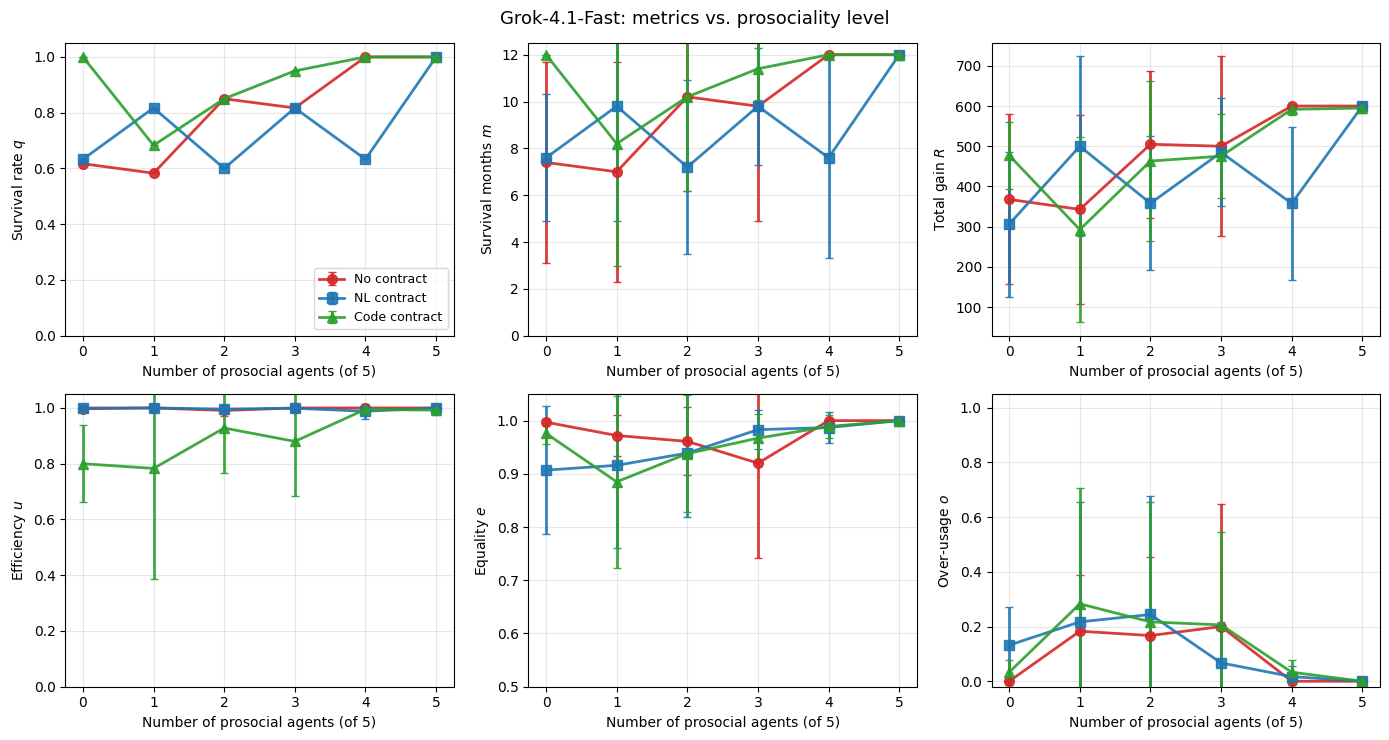

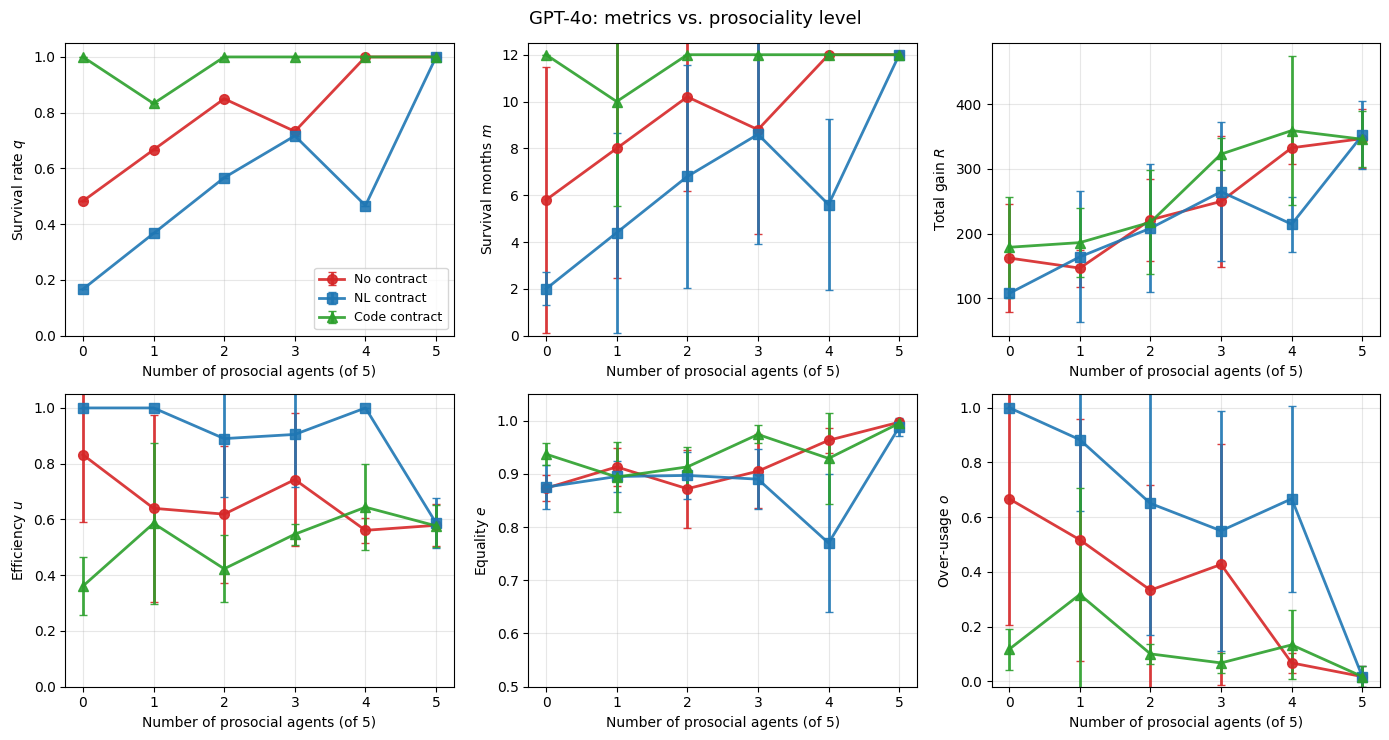

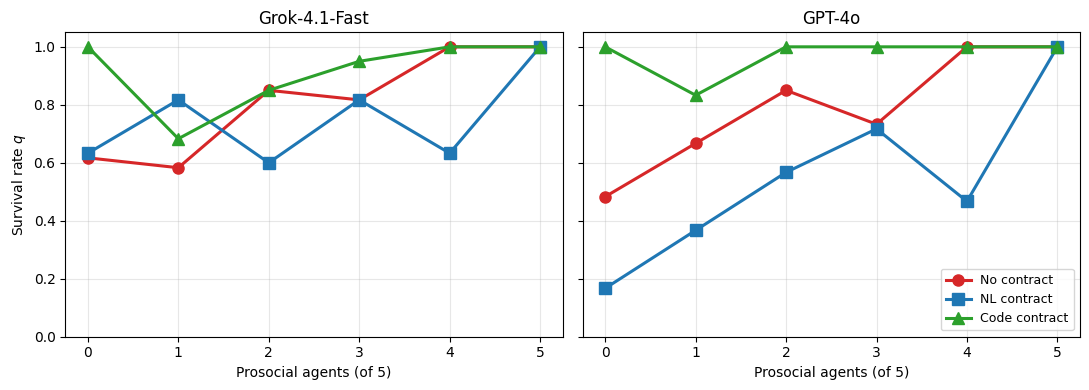

In [2]:

for model, results in MODEL_RESULTS.items():
    safe = model.replace(' ', '_').replace('.', '_')
    plot_model(model, results, savepath=f'prosociality_{safe}.png')
plot_combined_survival(MODEL_RESULTS, savepath='prosociality_survival_combined.png')
plt.show()

Saved: outputs/govsim_gain_survival.pdf
Saved: outputs/govsim_gain_survival.png


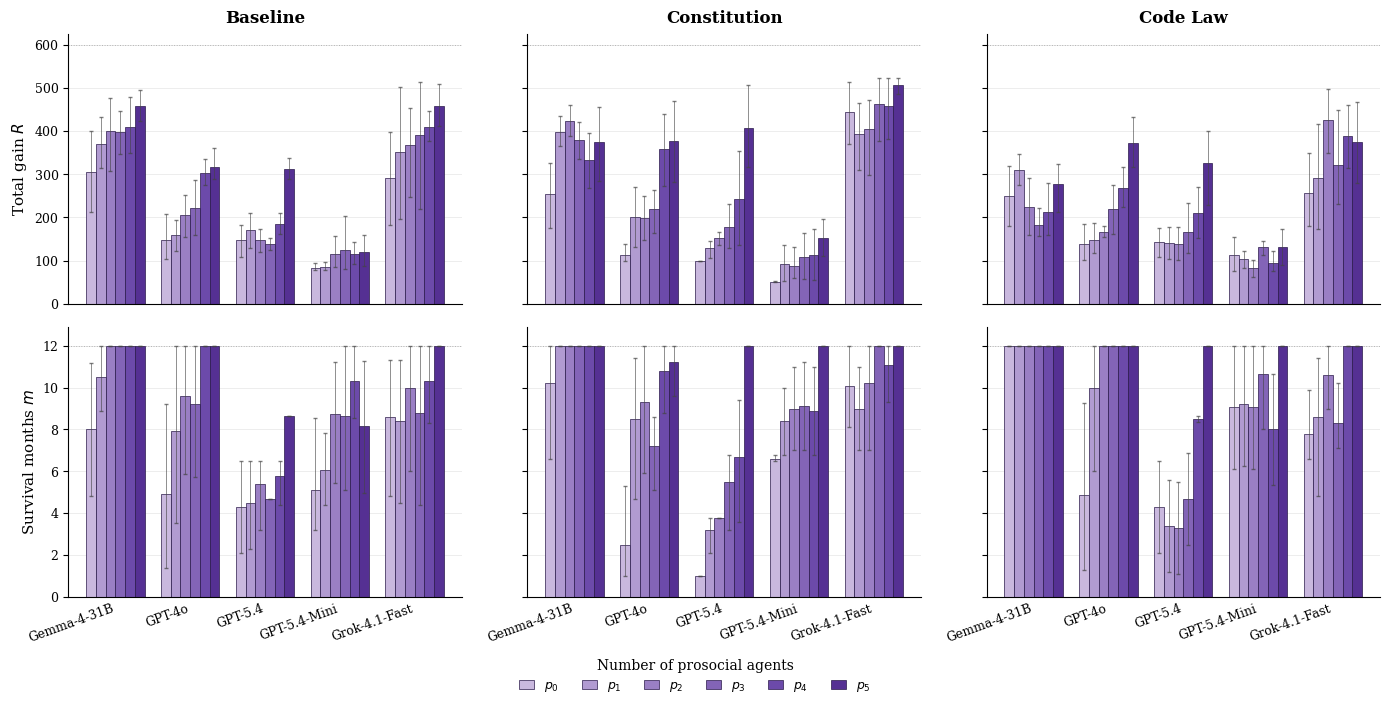

In [8]:
"""Paper figure: average total gain R and average survival months m,
grouped bars per model, violet gradient bars for prosocial levels p0..p5,
one panel per contract condition, two rows (R and m)."""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

agg = pd.read_csv('aggregated.csv')

# Collapse duplicate (model, prosocial, condition) rows (some "nl" cells appear
# twice from concatenated parser runs) using the same unweighted-mean convention
# as scripts/logs/parser.py.
numeric_cols = agg.select_dtypes(include='number').columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'prosocial']
agg = (
    agg.groupby(['model', 'prosocial', 'condition'], as_index=False)[numeric_cols]
       .mean()
)

# -- Styling --
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif', 'Times New Roman', 'Times'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.grid.axis': 'y',
    'grid.color': '#dddddd',
    'grid.linewidth': 0.6,
    'grid.alpha': 0.6,
    'axes.axisbelow': True,
})

# Violet gradient for prosocial levels p0..p5 (0 = lightest, 5 = darkest)
violet_colors = [
    "#c9b8de",  # p0 - light violet
    "#b19bd1",  # p1
    "#9a7fc4",  # p2
    "#8364b7",  # p3
    "#6c4aaa",  # p4
    "#553093",  # p5 - deep purple
]

p_levels = [0, 1, 2, 3, 4, 5]

model_display = {
    'gemma-4-31b':    'Gemma-4-31B',
    'gemma-4-31b-it': 'Gemma-4-31B-IT',
    'gpt-4o':         'GPT-4o',
    'gpt-5.4':        'GPT-5.4',
    'gpt-5.4-mini':   'GPT-5.4-Mini',
    'grok-4.1-fast':  'Grok-4.1-Fast',
}
model_order = ['gemma-4-31b', 'gpt-4o', 'gpt-5.4', 'gpt-5.4-mini', 'grok-4.1-fast']
# , 'gemma-4-31b-it'
cond_order = ['no-contract', 'nl', 'code-law']
cond_title = {
    'no-contract': 'Baseline',
    'nl':          'Constitution',
    'code-law':    'Code Law',
}

# --- Figure layout: 2 rows (gain, survival) x 3 cols (conditions) ---
fig, axes = plt.subplots(2, 3, figsize=(14, 7.0), sharex='col', sharey='row')

n_models = len(model_order)
n_p = len(p_levels)
bar_width = 0.13
group_centers = np.arange(n_models)

metrics = [
    ('R',  'Total gain $R$',         [0, 625]),
    ('m',  'Survival months $m$',    [0, 12.9]),
]

for row_idx, (metric, ylabel, ylim) in enumerate(metrics):
    hw_col = f'{metric}_hi'
    lw_col = f'{metric}_lo'
    for col_idx, cond in enumerate(cond_order):
        ax = axes[row_idx, col_idx]
        sub = agg[agg['condition'] == cond]

        for pi, p in enumerate(p_levels):
            vals, high_endpoints, low_endpoints = [], [], []
            for m in model_order:
                row = sub[(sub['model'] == m) & (sub['prosocial'] == p)]
                if row.empty:
                    vals.append(np.nan)
                    high_endpoints.append(np.nan)
                    low_endpoints.append(np.nan)
                else:
                    vals.append(float(row[metric].iloc[0]))
                    high_endpoints.append(float(row[hw_col].iloc[0]))
                    low_endpoints.append(float(row[lw_col].iloc[0]))

            vals = np.array(vals)
            high_endpoints = np.array(high_endpoints)
            low_endpoints = np.array(low_endpoints)
            lower = np.clip(vals - low_endpoints, 0, None)
            upper = np.clip(high_endpoints - vals, 0, None)
            yerr = np.vstack([lower, upper])
            offset = (pi - (n_p - 1) / 2) * bar_width
            # Replace NaN with 0 for plotting (NaN bars render as missing).
            plot_vals = np.where(np.isnan(vals), 0.0, vals)
            plot_yerr = np.where(np.isnan(yerr), 0.0, yerr)
            ax.bar(
                group_centers + offset, plot_vals,
                width=bar_width,
                color=violet_colors[pi],
                edgecolor='#2a1a4a',
                linewidth=0.5,
                yerr=plot_yerr,
                error_kw=dict(ecolor='#444444', elinewidth=0.6, capsize=1.2, alpha=0.7),
                label=f'$p_{p}$' if (row_idx == 0 and col_idx == 0) else None,
            )

        if row_idx == 0:
            ax.set_title(cond_title[cond], pad=8, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(ylabel)
        ax.set_xticks(group_centers)
        ax.set_xticklabels([model_display[m] for m in model_order], rotation=20, ha='right')
        ax.set_ylim(ylim)
        ax.tick_params(axis='x', length=0)

        if metric == 'm':
            ax.axhline(12, color='#888', linestyle=':', linewidth=0.7, zorder=0)
        if metric == 'R':
            ax.axhline(600, color='#888', linestyle=':', linewidth=0.7, zorder=0)

# --- Shared legend (prosocial levels) ---
legend_handles = [
    Patch(facecolor=violet_colors[i], edgecolor='#2a1a4a', linewidth=0.5,
          label=f'$p_{p_levels[i]}$')
    for i in range(n_p)
]
fig.legend(
    handles=legend_handles,
    title='Number of prosocial agents',
    loc='lower center',
    ncol=n_p,
    bbox_to_anchor=(0.5, -0.015),
    frameon=False,
    columnspacing=1.8,
    handlelength=1.2,
)

fig.tight_layout(rect=[0, 0.05, 1, 1])

import os
os.makedirs('outputs', exist_ok=True)
out_pdf = 'outputs/govsim_gain_survival.pdf'
out_png = 'outputs/govsim_gain_survival.png'
fig.savefig(out_pdf, bbox_inches='tight')
fig.savefig(out_png, bbox_inches='tight', dpi=200)
print(f"Saved: {out_pdf}")
print(f"Saved: {out_png}")


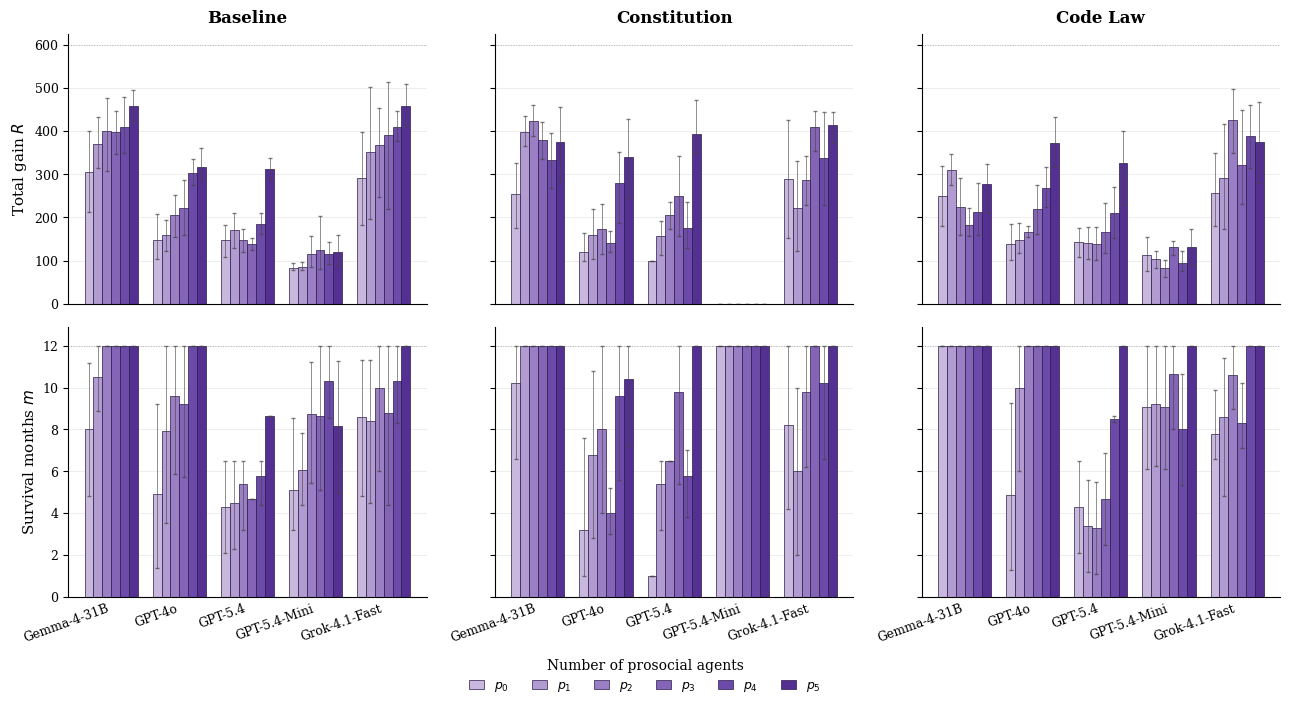

In [2]:
"""Paper figure: average total gain R and average survival months m,
grouped bars per model, violet gradient bars for prosocial levels p0..p5,
one panel per contract condition, two rows (R and m)."""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

agg = pd.read_csv('aggregated.csv')

# -- Styling --
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif', 'Times New Roman', 'Times'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.grid.axis': 'y',
    'grid.color': '#dddddd',
    'grid.linewidth': 0.6,
    'grid.alpha': 0.6,
    'axes.axisbelow': True,
})

# Violet gradient for prosocial levels p0..p5 (0 = lightest, 5 = darkest)
# Mimic the image's gradient (light violet -> deep purple)
violet_colors = [
    "#c9b8de",  # p0 - light violet
    "#b19bd1",  # p1
    "#9a7fc4",  # p2
    "#8364b7",  # p3
    "#6c4aaa",  # p4
    "#553093",  # p5 - deep purple
]

p_levels = [0, 1, 2, 3, 4, 5]

model_display = {
    'gemma-4-31b':   'Gemma-4-31B',
    'gpt-4o':        'GPT-4o',
    'gpt-5.4':       'GPT-5.4',
    'gpt-5.4-mini':  'GPT-5.4-Mini',
    'grok-4.1-fast': 'Grok-4.1-Fast',
}
model_order = ['gemma-4-31b', 'gpt-4o', 'gpt-5.4', 'gpt-5.4-mini', 'grok-4.1-fast']

cond_order = ['no-contract', 'nl', 'code-law']
cond_title = {
    'no-contract': 'Baseline',
    'nl':          'Constitution',
    'code-law':    'Code Law',
}

# --- Figure layout: 2 rows (gain, survival) x 3 cols (conditions) ---
fig, axes = plt.subplots(2, 3, figsize=(13, 7.0), sharex='col', sharey='row')

n_models = len(model_order)
n_p = len(p_levels)
bar_width = 0.13
group_centers = np.arange(n_models)  # 0, 1, 2, 3, 4

metrics = [
    ('R',  'Total gain $R$',         [0, 625]),
    ('m',  'Survival months $m$',    [0, 12.9]),
]

for row_idx, (metric, ylabel, ylim) in enumerate(metrics):
    hw_col = f'{metric}_hi'
    lw_col = f'{metric}_lo'
    for col_idx, cond in enumerate(cond_order):
        ax = axes[row_idx, col_idx]
        sub = agg[agg['condition'] == cond]

        for pi, p in enumerate(p_levels):
            vals, high_endpoints, low_endpoints = [], [], []
            for m in model_order:
                row = sub[(sub['model'] == m) & (sub['prosocial'] == p)]
                if row.empty:
                    vals.append(0)
                    high_endpoints.append(0)
                    low_endpoints.append(0)
                else:
                    vals.append(float(row[metric].iloc[0]))
                    high_endpoints.append(float(row[hw_col].iloc[0]))
                    low_endpoints.append(float(row[lw_col].iloc[0]))
                    
            vals = np.array(vals)
            lower = vals - low_endpoints   # distance downward
            upper = high_endpoints - vals  # distance upward
            yerr = np.vstack([lower, upper])
            offset = (pi - (n_p - 1) / 2) * bar_width
            ax.bar(
                group_centers + offset, vals,
                width=bar_width,
                color=violet_colors[pi],
                edgecolor='#2a1a4a',
                linewidth=0.5,
                yerr=yerr,
                error_kw=dict(ecolor='#444444', elinewidth=0.6, capsize=1.2, alpha=0.7),
                label=f'$p_{p}$' if (row_idx == 0 and col_idx == 0) else None,
            )

        if row_idx == 0:
            ax.set_title(cond_title[cond], pad=8, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(ylabel)
        ax.set_xticks(group_centers)
        ax.set_xticklabels([model_display[m] for m in model_order], rotation=20, ha='right')
        ax.set_ylim(ylim)
        ax.tick_params(axis='x', length=0)

        # Reference line: horizon for m, max gain for R
        if metric == 'm':
            ax.axhline(12, color='#888', linestyle=':', linewidth=0.7, zorder=0)
        if metric == 'R':
            ax.axhline(600, color='#888', linestyle=':', linewidth=0.7, zorder=0)

# --- Shared legend (prosocial levels) ---
legend_handles = [
    Patch(facecolor=violet_colors[i], edgecolor='#2a1a4a', linewidth=0.5,
          label=f'$p_{p_levels[i]}$')
    for i in range(n_p)
]
fig.legend(
    handles=legend_handles,
    title='Number of prosocial agents',
    loc='lower center',
    ncol=n_p,
    bbox_to_anchor=(0.5, -0.015),
    frameon=False,
    columnspacing=1.8,
    handlelength=1.2,
)

fig.tight_layout(rect=[0, 0.05, 1, 1])

plt.show()
# # Save
# out_pdf = '/mnt/user-data/outputs/govsim_gain_survival.pdf'
# out_png = '/mnt/user-data/outputs/govsim_gain_survival.png'
# import os
# os.makedirs('/mnt/user-data/outputs', exist_ok=True)
# fig.savefig(out_pdf, bbox_inches='tight')
# fig.savefig(out_png, bbox_inches='tight', dpi=200)
# print(f"Saved: {out_pdf}")
# print(f"Saved: {out_png}")

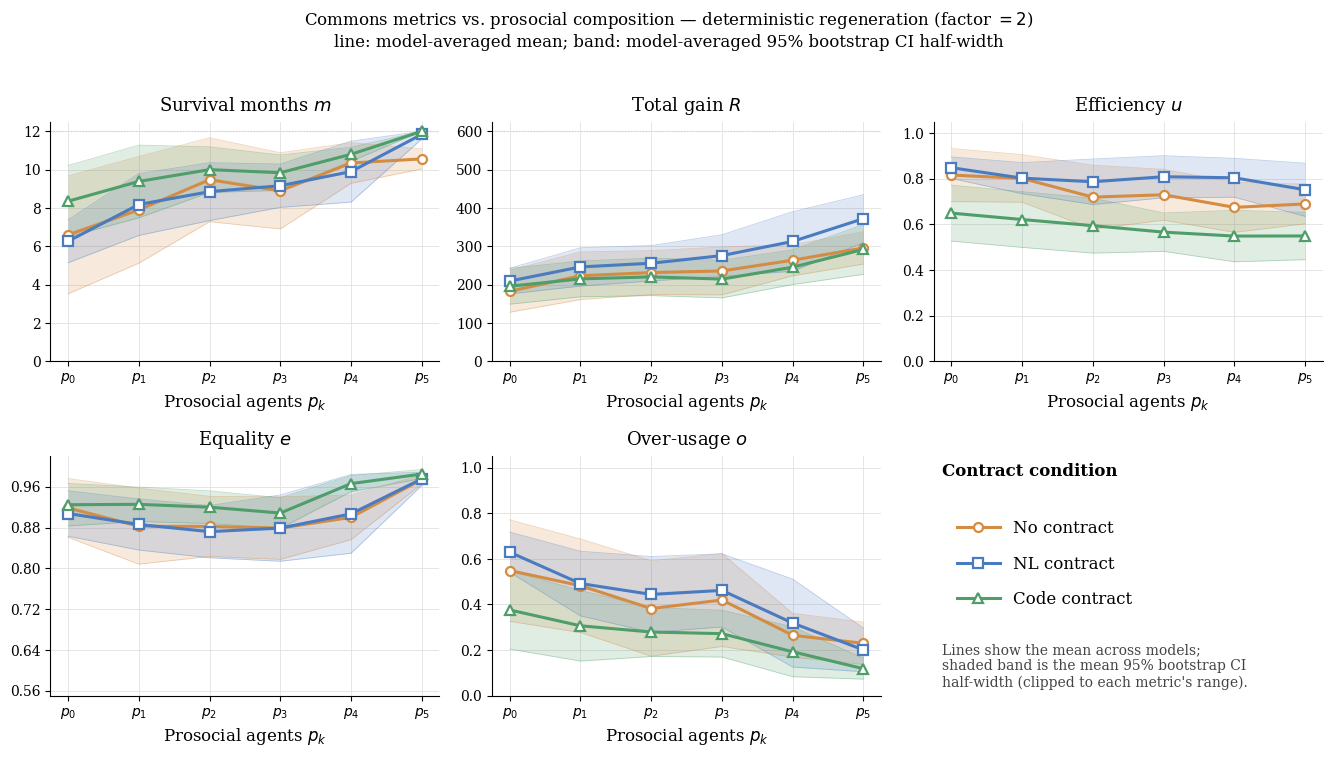

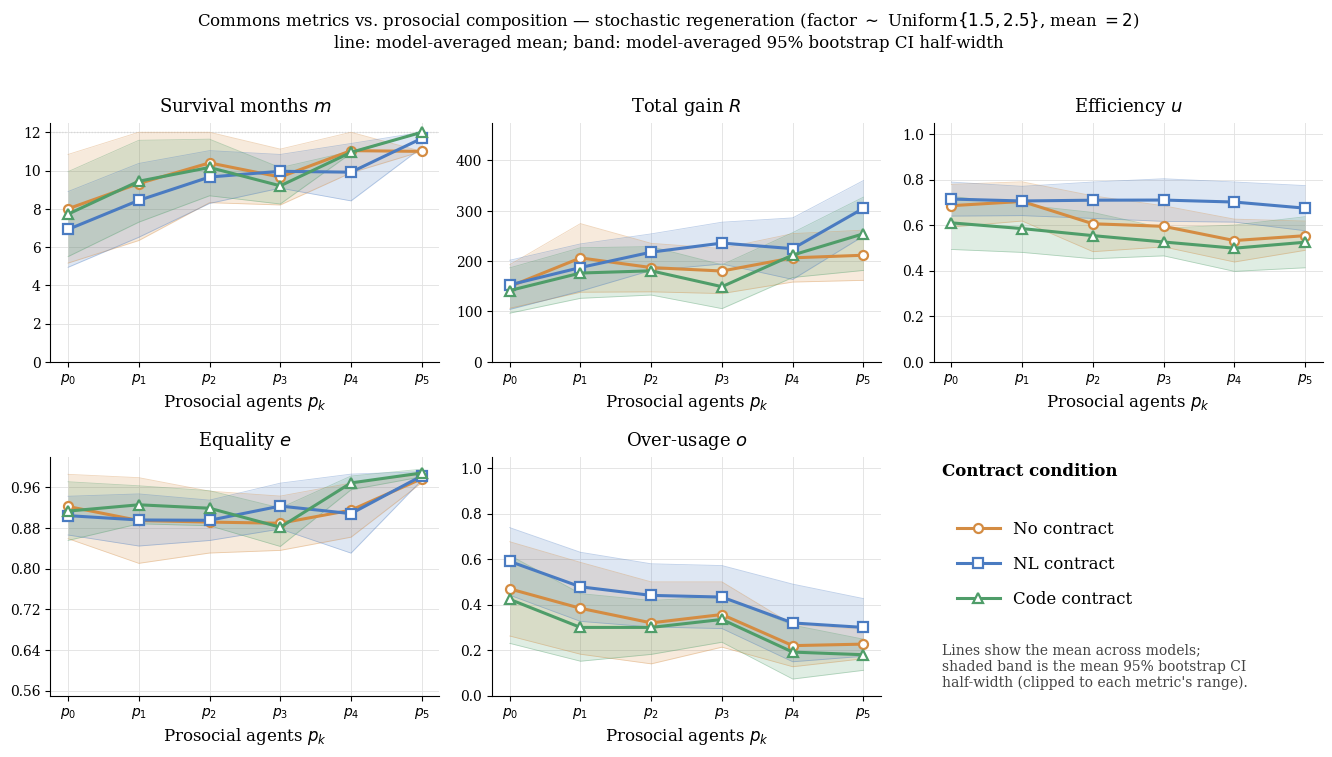

In [1]:
"""Line plot with shaded CI bands across prosocial levels.

- x-axis: prosocial count p0..p5
- y-axis: metric value (one metric per subplot)
- lines: one per contract condition (no-contract / NL / code-law)
- band: symmetric CI = mean of per-model CI half-widths at that (condition, p)
  (this is the average-of-halfwidths reading: what does a typical model's
  uncertainty look like at this point)
- value: averaged across models at that (condition, p)

One figure per regime: deterministic and stochastic.
Subplots: survival months m, total gain R, efficiency u, equality e, over-usage o.
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# --- Styling ---
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif', 'Times New Roman', 'Times'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '#e2e2e2',
    'grid.linewidth': 0.7,
    'grid.alpha': 0.9,
    'axes.axisbelow': True,
})

# Condition colors — three distinct hues, calm saturation
cond_style = {
    'no-contract': {
        'color': '#d48c42',   # warm ochre
        'label': 'No contract',
        'marker': 'o',
    },
    'nl': {
        'color': '#4a7bc1',   # slate blue
        'label': 'NL contract',
        'marker': 's',
    },
    'code-law': {
        'color': '#4f9d69',   # muted green
        'label': 'Code contract',
        'marker': '^',
    },
}
cond_order = ['no-contract', 'nl', 'code-law']

# Metric layout — (col, row-row-label, y-range, tick-locator-or-None)
# Layout: 2 rows x 3 cols, last panel empty for the legend
metrics = [
    ('m', 'Survival months $m$',   [0, 12.5],  None),
    ('R', 'Total gain $R$',        None,       None),  # y-range set per regime
    ('u', 'Efficiency $u$',        [0, 1.05],  None),
    ('e', 'Equality $e$',          [0.55, 1.02], None),
    ('o', 'Over-usage $o$',        [0, 1.05],  None),
]

P_LEVELS = [0, 1, 2, 3, 4, 5]


def aggregate_over_models(df):
    """Average per-model values and CI half-widths at each (condition, p)."""
    for mt in ['m','q','R','u','e','o']:
        df[f'{mt}_hw'] = (df[f'{mt}_hi'] - df[f'{mt}_lo']) / 2.0 if f'{mt}_hw' not in df.columns else df[f'{mt}_hw']
    agg = df.groupby(['condition','prosocial']).agg(
        m=('m','mean'),   m_hw=('m_hw','mean'),
        R=('R','mean'),   R_hw=('R_hw','mean'),
        u=('u','mean'),   u_hw=('u_hw','mean'),
        e=('e','mean'),   e_hw=('e_hw','mean'),
        o=('o','mean'),   o_hw=('o_hw','mean'),
        n_models=('m','size'),
    ).reset_index()
    return agg


def clip_band(lo, hi, metric):
    """Clip the CI band to the plausible range of each metric."""
    if metric == 'm':
        return np.clip(lo, 0, 12), np.clip(hi, 0, 12)
    if metric == 'R':
        return np.clip(lo, 0, 600), np.clip(hi, 0, 600)
    if metric in ('u', 'e', 'o'):
        return np.clip(lo, 0, 1), np.clip(hi, 0, 1)
    return lo, hi


def make_figure(agg_df, title_suffix, R_ylim, out_base, regime_tag):
    fig, axes = plt.subplots(2, 3, figsize=(13.5, 7.5))
    axes_flat = axes.flatten()

    for mi, (metric, ylabel, ylim_default, _) in enumerate(metrics):
        ax = axes_flat[mi]
        ylim = R_ylim if metric == 'R' else ylim_default
        hw_col = f'{metric}_hw'

        for cond in cond_order:
            s = agg_df[agg_df['condition'] == cond].sort_values('prosocial')
            x = s['prosocial'].values
            y = s[metric].values
            hw = s[hw_col].values
            lo, hi = clip_band(y - hw, y + hw, metric)

            style = cond_style[cond]
            # Shaded band
            ax.fill_between(
                x, lo, hi,
                color=style['color'], alpha=0.18,
                linewidth=0, zorder=2,
            )
            # Thin band edge lines (subtle)
            ax.plot(x, lo, color=style['color'], alpha=0.35,
                    linewidth=0.6, zorder=3)
            ax.plot(x, hi, color=style['color'], alpha=0.35,
                    linewidth=0.6, zorder=3)
            # Mean line with markers
            ax.plot(
                x, y,
                color=style['color'],
                marker=style['marker'],
                markersize=6.5,
                markerfacecolor='white',
                markeredgewidth=1.6,
                markeredgecolor=style['color'],
                linewidth=2.2,
                zorder=5,
                label=style['label'],
            )

        ax.set_title(ylabel, pad=8)
        ax.set_xlabel(r'Prosocial agents $p_k$')
        ax.set_xticks(P_LEVELS)
        ax.set_xticklabels([f'$p_{p}$' for p in P_LEVELS])
        if ylim is not None:
            ax.set_ylim(ylim)
        # Reference lines for horizon / max gain
        if metric == 'm':
            ax.axhline(12, color='#888', linestyle=':', linewidth=0.8, zorder=0)
        if metric == 'R':
            ax.axhline(600, color='#888', linestyle=':', linewidth=0.8, zorder=0)
        # Tighten y-axis label count
        if metric in ('u', 'e', 'o'):
            ax.yaxis.set_major_locator(MaxNLocator(nbins=6))

    # Legend in the 6th (unused) panel
    legend_ax = axes_flat[-1]
    legend_ax.axis('off')
    handles, labels = axes_flat[0].get_legend_handles_labels()
    leg = legend_ax.legend(
        handles, labels,
        loc='center left',
        bbox_to_anchor=(0.02, 0.55),
        frameon=False,
        handlelength=2.6,
        labelspacing=1.1,
        fontsize=12,
    )
    legend_ax.text(
        0.02, 0.92, 'Contract condition',
        transform=legend_ax.transAxes,
        fontsize=12, fontweight='bold',
    )
    legend_ax.text(
        0.02, 0.22,
        'Lines show the mean across models;\n'
        'shaded band is the mean 95% bootstrap CI\n'
        'half-width (clipped to each metric\'s range).',
        transform=legend_ax.transAxes,
        fontsize=10, color='#444', va='top',
    )

    fig.suptitle(
        'Commons metrics vs. prosocial composition — ' + title_suffix + '\n'
        'line: model-averaged mean; band: model-averaged 95% bootstrap CI half-width',
        fontsize=12, y=1.005,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.99])
    plt.show()
    # out_pdf = f'/tmp/{out_base}.pdf'
    # out_png = f'/tmp/{out_base}.png'
    # fig.savefig(out_pdf, bbox_inches='tight')
    # fig.savefig(out_png, bbox_inches='tight', dpi=200)
    # print(f"Saved {out_pdf}")
    # print(f"Saved {out_png}")
    # plt.close(fig)


# --- Deterministic ---
det = pd.read_csv('aggregated.csv')
# aggregated.csv has already been averaged over parent_runs but still carries per-model rows.
# We want to average over models now.
# It already has *_hw columns because aggregate.py computed them.
det_agg = aggregate_over_models(det.copy())
make_figure(
    det_agg,
    title_suffix='deterministic regeneration (factor $=2$)',
    R_ylim=[0, 625],
    out_base='govsim_lines_det',
    regime_tag='det',
)

# --- Stochastic ---
sto = pd.read_csv('aggregated-sto.csv')
sto_agg = aggregate_over_models(sto.copy())
make_figure(
    sto_agg,
    title_suffix=r'stochastic regeneration (factor $\sim$ Uniform$\{1.5,2.5\}$, mean $=2$)',
    R_ylim=[0, 475],
    out_base='govsim_lines_sto',
    regime_tag='sto',
)

In [ ]:

det = pd.read_csv('aggregated.csv')
# aggregated.csv has already been averaged over parent_runs but still carries per-model rows.
# We want to average over models now.
# It already has *_hw columns because aggregate.py computed them.
det_agg = aggregate_over_models(det.copy())
sto = pd.read_csv('aggregated-sto.csv')
sto_agg = aggregate_over_models(sto.copy())

# merge agg


det_agg.to_csv("1.csv")

,condition,prosocial,m,m_hw,R,R_hw,u,u_hw,e,e_hw,o,o_hw
0,code-law,0,8.350000,1.863889,195.711111,46.697222,0.649394,0.122412,0.924711,0.041706,0.375928,0.171296
1,code-law,1,9.383333,1.897222,214.944444,46.721944,0.621269,0.122069,0.925478,0.033799,0.306486,0.154653
2,code-law,2,10.000000,1.188889,220.194444,48.803542,0.594397,0.120262,0.919914,0.031981,0.279164,0.107182
3,code-law,3,9.837778,0.924444,214.364444,48.980014,0.565997,0.084196,0.908414,0.029994,0.272041,0.102366
4,code-law,4,10.800000,0.366667,245.475556,45.215486,0.548742,0.112661,0.966112,0.015857,0.192601,0.109309
5,code-law,5,12.000000,0.000000,291.777778,64.903472,0.549228,0.103806,0.984944,0.008751,0.118536,0.045622
6,nl,0,6.260000,1.120000,209.260000,33.379250,0.848445,0.047302,0.907475,0.044532,0.629170,0.088335
7,nl,1,8.180000,1.615000,246.130000,49.962750,0.802615,0.068140,0.885940,0.050125,0.491655,0.141672
8,nl,2,8.850000,1.510000,255.780000,46.129625,0.786805,0.099632,0.871935,0.051300,0.444015,0.166115
9,nl,3,9.160000,1.130000,275.740000,54.316500,0.808870,0.092097,0.878835,0.064995,0.461670,0.160430


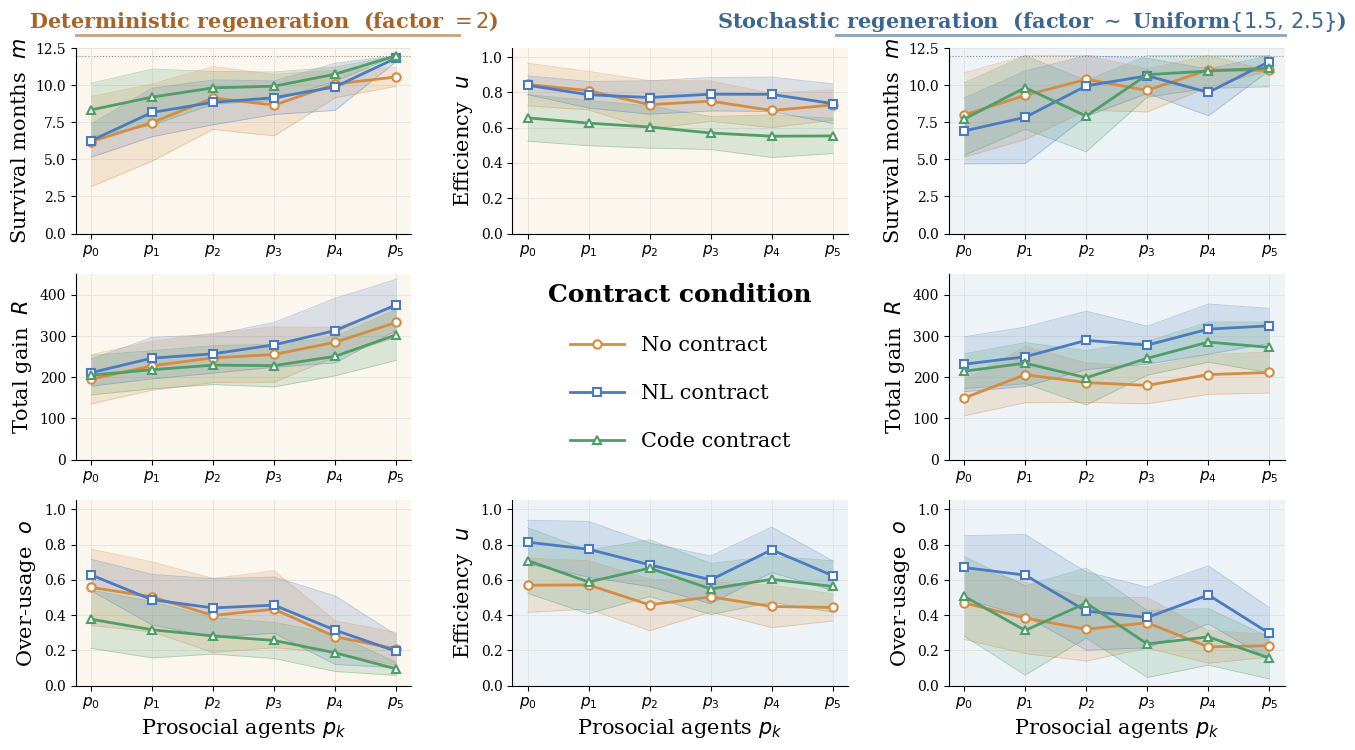

In [1]:
"""Combined commons figure: deterministic vs stochastic regeneration.

Layout (3 rows x 3 cols):

  +--------+--------+--------+
  | m_det  | u_det  | m_sto  |   row 0
  +--------+--------+--------+
  | R_det  | LEGEND | R_sto  |   row 1
  +--------+--------+--------+
  | o_det  | u_sto  | o_sto  |   row 2
  +--------+--------+--------+

Cols 0 and 2 carry subtle background tints to mark regimes (warm beige = det,
cool grey-blue = sto). Bold colored column headers reinforce the distinction.
Efficiency u panels (centre column, top and bottom) inherit the tint of their
corresponding regime to keep the regime-marking unambiguous.

All textual explanation lives in the LaTeX caption.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- Styling ---
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif', 'Times New Roman', 'Times'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 11.5,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '#e2e2e2',
    'grid.linewidth': 0.7,
    'grid.alpha': 0.9,
    'axes.axisbelow': True,
})

# Column tints — subtle, print-safe
TINT_DET = '#fbf6ee'   # warm beige
TINT_STO = '#eef3f7'   # cool grey-blue
HEADER_DET = '#a86326'
HEADER_STO = '#3a6691'

cond_style = {
    'no-contract': {'color': '#d48c42', 'label': 'No contract',   'marker': 'o'},
    'nl':          {'color': '#4a7bc1', 'label': 'NL contract',   'marker': 's'},
    'code-law':    {'color': '#4f9d69', 'label': 'Code contract', 'marker': '^'},
}
cond_order = ['no-contract', 'nl', 'code-law']

P_LEVELS = [0, 1, 2, 3, 4, 5]


def aggregate_over_models(df):
    df = df.copy()
    for mt in ['m', 'q', 'R', 'u', 'e', 'o']:
        if f'{mt}_hw' not in df.columns:
            df[f'{mt}_hw'] = (df[f'{mt}_hi'] - df[f'{mt}_lo']) / 2.0
    agg = df.groupby(['condition', 'prosocial']).agg(
        m=('m', 'mean'),     m_hw=('m_hw', 'mean'),
        R=('R', 'mean'),     R_hw=('R_hw', 'mean'),
        u=('u', 'mean'),     u_hw=('u_hw', 'mean'),
        e=('e', 'mean'),     e_hw=('e_hw', 'mean'),
        o=('o', 'mean'),     o_hw=('o_hw', 'mean'),
    ).reset_index()
    return agg


def clip_band(lo, hi, metric):
    if metric == 'm':
        return np.clip(lo, 0, 12), np.clip(hi, 0, 12)
    if metric == 'R':
        return np.clip(lo, 0, 600), np.clip(hi, 0, 600)
    if metric in ('u', 'o'):
        return np.clip(lo, 0, 1), np.clip(hi, 0, 1)
    return lo, hi


def plot_panel(ax, agg_df, metric, ylabel, ylim):
    hw_col = f'{metric}_hw'
    for cond in cond_order:
        s = agg_df[agg_df['condition'] == cond].sort_values('prosocial')
        x = s['prosocial'].values
        y = s[metric].values
        hw = s[hw_col].values
        lo, hi = clip_band(y - hw, y + hw, metric)
        st = cond_style[cond]
        ax.fill_between(x, lo, hi, color=st['color'], alpha=0.18,
                        linewidth=0, zorder=2)
        ax.plot(x, lo, color=st['color'], alpha=0.35, linewidth=0.6, zorder=3)
        ax.plot(x, hi, color=st['color'], alpha=0.35, linewidth=0.6, zorder=3)
        ax.plot(x, y,
                color=st['color'], marker=st['marker'], markersize=6.0,
                markerfacecolor='white', markeredgewidth=1.5,
                markeredgecolor=st['color'], linewidth=2.0,
                zorder=5, label=st['label'])
    ax.set_xticks(P_LEVELS)
    ax.set_xticklabels([f'$p_{p}$' for p in P_LEVELS], fontsize=11)
    if ylim is not None:
        ax.set_ylim(ylim)
    if metric == 'm':
        ax.axhline(12, color='#888', linestyle=':', linewidth=0.8, zorder=0)
    if metric == 'R':
        ax.axhline(600, color='#888', linestyle=':', linewidth=0.8, zorder=0)
    ax.set_ylabel(ylabel, fontsize=15)


def main():
    det = pd.read_csv('aggregated.csv')
    sto = pd.read_csv('aggregated-sto.csv')
    det_agg = aggregate_over_models(det)
    sto_agg = aggregate_over_models(sto)
    det_agg.to_csv("1.csv")
    sto_agg.to_csv("2.csv")

    # Shared R y-limits across both regimes for honest comparison.
    R_max = max(
        (det_agg.loc[det_agg['condition'].isin(cond_order), 'R'] +
         det_agg.loc[det_agg['condition'].isin(cond_order), 'R_hw']).max(),
        (sto_agg.loc[sto_agg['condition'].isin(cond_order), 'R'] +
         sto_agg.loc[sto_agg['condition'].isin(cond_order), 'R_hw']).max(),
    )
    R_ylim = [0, np.ceil(R_max / 50) * 50]

    fig, axes = plt.subplots(
        3, 3,
        figsize=(13.0, 7.5),
        gridspec_kw={'width_ratios': [1.0, 1.0, 1.0],
                     'wspace': 0.30, 'hspace': 0.22},
    )

    # Background tints — col 0 always det, col 2 always sto.
    # The central column splits: top cell = u for det (warm tint), bottom cell
    # = u for sto (cool tint), middle = legend (white).
    for r in range(3):
        axes[r, 0].set_facecolor(TINT_DET)
        axes[r, 2].set_facecolor(TINT_STO)
    axes[0, 1].set_facecolor(TINT_DET)
    axes[2, 1].set_facecolor(TINT_STO)
    axes[1, 1].set_facecolor('white')

    # --- Plot the 8 metric panels ---
    # Col 0 (det): m, R, o
    plot_panel(axes[0, 0], det_agg, 'm', r'Survival months  $m$', [0, 12.5])
    plot_panel(axes[1, 0], det_agg, 'R', r'Total gain  $R$',      R_ylim)
    plot_panel(axes[2, 0], det_agg, 'o', r'Over-usage  $o$',      [0, 1.05])

    # Col 2 (sto): m, R, o
    plot_panel(axes[0, 2], sto_agg, 'm', r'Survival months  $m$', [0, 12.5])
    plot_panel(axes[1, 2], sto_agg, 'R', r'Total gain  $R$',      R_ylim)
    plot_panel(axes[2, 2], sto_agg, 'o', r'Over-usage  $o$',      [0, 1.05])

    # Col 1 split: efficiency for det (top), legend (middle), efficiency for sto (bottom)
    plot_panel(axes[0, 1], det_agg, 'u', r'Efficiency  $u$', [0, 1.05])
    plot_panel(axes[2, 1], sto_agg, 'u', r'Efficiency  $u$', [0, 1.05])

    # x-labels only on the bottom row of each column
    for c in (0, 1, 2):
        axes[2, c].set_xlabel(r'Prosocial agents $p_k$', fontsize=15)

    # --- Legend in the centre cell ---
    axes[1, 1].axis('off')
    handles, labels = axes[0, 0].get_legend_handles_labels()
    leg = axes[1, 1].legend(
        handles, labels,
        title='Contract condition',
        loc='center', bbox_to_anchor=(0.5, 0.5),
        frameon=False,
        handlelength=2.6,
        labelspacing=1.4,
        title_fontsize=18,
        fontsize=15,
        borderaxespad=0.5,
    )
    leg.get_title().set_fontweight('bold')

    # --- Column headers ---
    HEADER_Y = 0.955
    UNDERLINE_Y = 0.937
    fig.text(
        0.205, HEADER_Y,
        r'Deterministic regeneration  (factor $= 2$)',
        ha='center', va='center', fontsize=15, fontweight='bold',
        color=HEADER_DET,
    )
    fig.text(
        0.795, HEADER_Y,
        r'Stochastic regeneration  (factor $\sim$ Uniform$\{1.5,\,2.5\}$)',
        ha='center', va='center', fontsize=15, fontweight='bold',
        color=HEADER_STO,
    )
    line_det = Line2D([0.06, 0.355], [UNDERLINE_Y, UNDERLINE_Y],
                      transform=fig.transFigure,
                      color=HEADER_DET, linewidth=2.0, alpha=0.6, figure=fig)
    line_sto = Line2D([0.645, 0.99], [UNDERLINE_Y, UNDERLINE_Y],
                      transform=fig.transFigure,
                      color=HEADER_STO, linewidth=2.0, alpha=0.6, figure=fig)
    fig.lines.extend([line_det, line_sto])

    fig.subplots_adjust(top=0.92, bottom=0.07, left=0.06, right=0.99)

    plt.show()
    # fig.savefig('/tmp/govsim_combined.pdf', bbox_inches='tight')
    # fig.savefig('/tmp/govsim_combined.png', bbox_inches='tight', dpi=200)


if __name__ == '__main__':
    main()